In [1]:
import os
import shutil

sumber_dataset = "C:\\Users\\User\\Downloads\\Fold1_part1"

target_alert = "dataset/alert"
target_drowsy = "dataset/drowsy"

# Membuat folder target jika belum ada
os.makedirs(target_alert, exist_ok=True)
os.makedirs(target_drowsy, exist_ok=True)

print("Memulai proses pemisahan dataset...")
berhasil_dipindah = 0

# Berjalan menelusuri setiap folder dan subfolder di dalam hasil ekstrak
for root, dirs, files in os.walk(sumber_dataset):
    for file in files:
        # Ubah nama file ke huruf kecil semua agar seragam (menghindari error .MOV vs .mov)
        nama_file_lower = file.lower()
        
        # Mengecek apakah ini file video
        if nama_file_lower.endswith(('.mp4', '.mov', '.avi')):
            path_asal = os.path.join(root, file)
            
            # Mengambil ID partisipan dari nama folder induknya (misal folder "01", "02")
            nama_folder = os.path.basename(root)
            
            # Jika file adalah "0.mov" -> Masukkan ke folder alert
            if nama_file_lower.startswith('0.'):
                nama_baru = f"peserta_{nama_folder}_alert.mov"
                path_tujuan = os.path.join(target_alert, nama_baru)
                shutil.copy2(path_asal, path_tujuan) # Copy file
                berhasil_dipindah += 1
                
            # Jika file adalah "10.mov" -> Masukkan ke folder drowsy
            elif nama_file_lower.startswith('10.'):
                nama_baru = f"peserta_{nama_folder}_drowsy.mov"
                path_tujuan = os.path.join(target_drowsy, nama_baru)
                shutil.copy2(path_asal, path_tujuan) # Copy file
                berhasil_dipindah += 1

print(f"Selesai! Berhasil menyalin dan mengganti nama {berhasil_dipindah} video.")
print("File 5.mov (Low Vigilance) sengaja diabaikan untuk menjaga akurasi evaluasi biner.")

Memulai proses pemisahan dataset...
Selesai! Berhasil menyalin dan mengganti nama 12 video.
File 5.mov (Low Vigilance) sengaja diabaikan untuk menjaga akurasi evaluasi biner.


In [2]:
import cv2
import dlib
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from fatigue_detector import FatigueDetector

DATASET_DIR = "dataset"
SHAPE_PREDICTOR_PATH = "shape_predictor_68_face_landmarks.dat"

print("[INFO] Memuat model deteksi wajah Dlib...")
face_detector = dlib.get_frontal_face_detector()
landmark_predictor = dlib.shape_predictor(SHAPE_PREDICTOR_PATH)

(lStart, lEnd) = (42, 48)
(rStart, rEnd) = (36, 42)
print("[INFO] Setup selesai. Sistem siap digunakan.")

[INFO] Memuat model deteksi wajah Dlib...
[INFO] Setup selesai. Sistem siap digunakan.


In [5]:
def process_video(video_path, detector_logic):
    cap = cv2.VideoCapture(video_path)
    
    detector_logic.frame_counter = 0
    detector_logic.alarm_on = False
    
    predicted_drowsy = False
    frame_count = 0
    start_time = time.time()
    
    # ----------------------------------------------------
    # SETTING OPTIMASI: Cek setiap frame ke-3 (10 FPS)
    # ----------------------------------------------------
    frame_skip = 3 
    
    while True:
        ret, frame = cap.read()
        if not ret: 
            break
            
        frame_count += 1
        
        # LOMPATI FRAME INI JIKA BUKAN KELIPATAN 3
        if frame_count % frame_skip != 0:
            continue
            
        # Resize aman (menjaga rasio asli, anti-gepeng)
        h, w = frame.shape[:2]
        new_w = 500
        new_h = int((new_w / w) * h)
        frame_resized = cv2.resize(frame, (new_w, new_h))
        
        gray = cv2.cvtColor(frame_resized, cv2.COLOR_BGR2GRAY)
        faces = face_detector(gray, 0)
        
        for face in faces:
            shape = landmark_predictor(gray, face)
            landmarks = [(shape.part(i).x, shape.part(i).y) for i in range(68)]
            leftEye = landmarks[lStart:lEnd]
            rightEye = landmarks[rStart:rEnd]
            
            _, alarm_status = detector_logic.check_drowsiness(leftEye, rightEye)
            
            if alarm_status:
                predicted_drowsy = True
                break
                
        if predicted_drowsy:
            break
            
    end_time = time.time()
    cap.release()
    
    processing_time = end_time - start_time
    fps = (frame_count / frame_skip) / processing_time if processing_time > 0 else 0
    
    return 1 if predicted_drowsy else 0, fps

In [15]:
# Turunkan sensitivitas EAR dan naikkan batas frame (1.5 detik)
detector = FatigueDetector(ear_threshold=0.23, consecutive_frames=11)

y_true = []
y_pred = []
fps_list = []

print("=========================================")
print("[1/2] EVALUASI DATASET AMAN (ALERT)")
print("=========================================")
alert_dir = os.path.join(DATASET_DIR, "alert")
for filename in os.listdir(alert_dir):
    if filename.lower().endswith(('.mp4', '.mov', '.avi')):
        path = os.path.join(alert_dir, filename)
        pred, fps = process_video(path, detector)
        y_true.append(0)
        y_pred.append(pred)
        fps_list.append(fps)
        hasil = "BENAR (Aman)" if pred == 0 else "SALAH (False Positive)"
        print(f"Memproses {filename} -> {hasil}")

print("\n=========================================")
print("[2/2] EVALUASI DATASET NGANTUK (DROWSY)")
print("=========================================")
drowsy_dir = os.path.join(DATASET_DIR, "drowsy")
for filename in os.listdir(drowsy_dir):
    if filename.lower().endswith(('.mp4', '.mov', '.avi')):
        path = os.path.join(drowsy_dir, filename)
        pred, fps = process_video(path, detector)
        y_true.append(1)
        y_pred.append(pred)
        fps_list.append(fps)
        hasil = "BENAR (Ngantuk)" if pred == 1 else "SALAH (False Negative)"
        print(f"Memproses {filename} -> {hasil}")

print("\n[INFO] Seluruh dataset berhasil dievaluasi!")

[1/2] EVALUASI DATASET AMAN (ALERT)
Memproses peserta_01_alert.mov -> BENAR (Aman)
Memproses peserta_02_alert.mov -> SALAH (False Positive)
Memproses peserta_03_alert.mov -> BENAR (Aman)
Memproses peserta_04_alert.mov -> BENAR (Aman)
Memproses peserta_05_alert.mov -> BENAR (Aman)
Memproses peserta_06_alert.mov -> BENAR (Aman)

[2/2] EVALUASI DATASET NGANTUK (DROWSY)
Memproses peserta_01_drowsy.mov -> BENAR (Ngantuk)
Memproses peserta_02_drowsy.mov -> SALAH (False Negative)
Memproses peserta_03_drowsy.mov -> BENAR (Ngantuk)
Memproses peserta_04_drowsy.mov -> SALAH (False Negative)
Memproses peserta_05_drowsy.mov -> BENAR (Ngantuk)
Memproses peserta_06_drowsy.mov -> BENAR (Ngantuk)

[INFO] Seluruh dataset berhasil dievaluasi!


KESIMPULAN EVALUASI SISTEM

[CLASSIFICATION REPORT]
              precision    recall  f1-score   support

   Alert (0)       0.71      0.83      0.77         6
  Drowsy (1)       0.80      0.67      0.73         6

    accuracy                           0.75        12
   macro avg       0.76      0.75      0.75        12
weighted avg       0.76      0.75      0.75        12


[PERFORMA SISTEM]
Kecepatan Proses Rata-rata: 29.55 Frames Per Second (FPS)


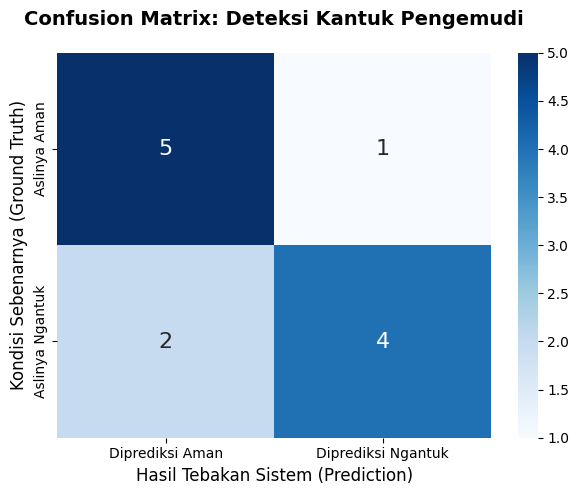

In [16]:
print("=========================================")
print("KESIMPULAN EVALUASI SISTEM")
print("=========================================")

# 1. Menampilkan Laporan Metrik
print("\n[CLASSIFICATION REPORT]")
print(classification_report(y_true, y_pred, target_names=['Alert (0)', 'Drowsy (1)']))

# 2. Menampilkan Rata-rata FPS
avg_fps = np.mean(fps_list) if fps_list else 0
print(f"\n[PERFORMA SISTEM]")
print(f"Kecepatan Proses Rata-rata: {avg_fps:.2f} Frames Per Second (FPS)")

# 3. Menggambar Heatmap Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Diprediksi Aman', 'Diprediksi Ngantuk'],
            yticklabels=['Aslinya Aman', 'Aslinya Ngantuk'],
            annot_kws={"size": 16}) # Memperbesar angka di dalam kotak

plt.title('Confusion Matrix: Deteksi Kantuk Pengemudi', pad=20, size=14, weight='bold')
plt.ylabel('Kondisi Sebenarnya (Ground Truth)', size=12)
plt.xlabel('Hasil Tebakan Sistem (Prediction)', size=12)
plt.show()

In [14]:
import os
from sklearn.metrics import accuracy_score, precision_score, recall_score
from fatigue_detector import FatigueDetector

ear_grid = [0.21, 0.23, 0.24] 
frame_grid = [11, 13, 14]

print("=========================================")
print("MEMULAI GRID SEARCH (STRATEGI: MAX RECALL)")
print("=========================================")

# Siapkan list video
alert_dir = os.path.join(DATASET_DIR, "alert")
drowsy_dir = os.path.join(DATASET_DIR, "drowsy")

alert_files = [os.path.join(alert_dir, f) for f in os.listdir(alert_dir) if f.lower().endswith(('.mp4', '.mov'))]
drowsy_files = [os.path.join(drowsy_dir, f) for f in os.listdir(drowsy_dir) if f.lower().endswith(('.mp4', '.mov'))]

best_recall = -1 # Kita ubah patokannya menjadi Recall
best_params = {'ear': 0, 'frames': 0, 'acc': 0, 'prec': 0, 'rec': 0}
semua_hasil = []

kombinasi_ke = 1
total_kombinasi = len(ear_grid) * len(frame_grid)

for ear in ear_grid:
    for frames in frame_grid:
        print(f"\n[Eksperimen {kombinasi_ke}/{total_kombinasi}] Menguji EAR: {ear} | Frames: {frames}...")
        detector = FatigueDetector(ear_threshold=ear, consecutive_frames=frames)
        
        y_true = []
        y_pred = []
        
        for filepath in alert_files:
            pred, _ = process_video(filepath, detector)
            y_true.append(0)
            y_pred.append(pred)
            
        for filepath in drowsy_files:
            pred, _ = process_video(filepath, detector)
            y_true.append(1)
            y_pred.append(pred)
            
        # Hitung Skor
        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)
        
        print(f"Hasil -> Recall: {rec*100:.1f}% | Precision: {prec*100:.1f}% | Accuracy: {acc*100:.1f}%")
        
        semua_hasil.append({
            'ear': ear, 'frames': frames,
            'acc': acc, 'prec': prec, 'rec': rec
        })
        
        # ==========================================
        # LOGIKA STRATEGI BARU: PRIORITAS RECALL
        # ==========================================
        # 1. Jika Recall lebih tinggi, langsung jadikan juara baru
        if rec > best_recall:
            best_recall = rec
            best_params = {'ear': ear, 'frames': frames, 'acc': acc, 'prec': prec, 'rec': rec}
        
        # 2. Jika Recall sama kuat, pilih yang Precision-nya lebih aman (Tie-breaker)
        elif rec == best_recall and prec > best_params['prec']:
            best_params = {'ear': ear, 'frames': frames, 'acc': acc, 'prec': prec, 'rec': rec}
            
        kombinasi_ke += 1

print("\n" + "="*50)
print("🏆 PENCARIAN SELESAI (STRATEGI RECALL) 🏆")
print("="*50)
print(f"EAR Threshold Terbaik    : {best_params['ear']}")
print(f"Consecutive Frames       : {best_params['frames']}")
print(f"Recall (Prioritas Utama) : {best_params['rec']*100:.1f}%")
print(f"Precision Pendamping     : {best_params['prec']*100:.1f}%")
print(f"Akurasi Keseluruhan      : {best_params['acc']*100:.1f}%")
print("="*50)

MEMULAI GRID SEARCH (STRATEGI: MAX RECALL)

[Eksperimen 1/9] Menguji EAR: 0.21 | Frames: 11...
Hasil -> Recall: 50.0% | Precision: 100.0% | Accuracy: 75.0%

[Eksperimen 2/9] Menguji EAR: 0.21 | Frames: 13...
Hasil -> Recall: 50.0% | Precision: 100.0% | Accuracy: 75.0%

[Eksperimen 3/9] Menguji EAR: 0.21 | Frames: 14...
Hasil -> Recall: 50.0% | Precision: 100.0% | Accuracy: 75.0%

[Eksperimen 4/9] Menguji EAR: 0.23 | Frames: 11...
Hasil -> Recall: 66.7% | Precision: 80.0% | Accuracy: 75.0%

[Eksperimen 5/9] Menguji EAR: 0.23 | Frames: 13...
Hasil -> Recall: 50.0% | Precision: 75.0% | Accuracy: 66.7%

[Eksperimen 6/9] Menguji EAR: 0.23 | Frames: 14...
Hasil -> Recall: 50.0% | Precision: 75.0% | Accuracy: 66.7%

[Eksperimen 7/9] Menguji EAR: 0.24 | Frames: 11...
Hasil -> Recall: 66.7% | Precision: 57.1% | Accuracy: 58.3%

[Eksperimen 8/9] Menguji EAR: 0.24 | Frames: 13...
Hasil -> Recall: 66.7% | Precision: 66.7% | Accuracy: 66.7%

[Eksperimen 9/9] Menguji EAR: 0.24 | Frames: 14...
Hasil 